# ICS 604: Assignment 3
# Hypothesis Testing and Statistical Inference

<div class="alert alert-block alert-danger" style="font-size: 20px; font-weight: bold;">
    Due Date: 11:59 PM on Monday, April 6
</div>

## Your Name: Nicholas Fairhart
---

## Submission Instructions

1. Name your notebook file using your last and first name:
    - `[LastName][FirstName]_[AssignmentNumber].ipynb` (E.g., BaekKay_3.ipynb)
2. **Submit only the Jupyter Notebook file (`.ipynb`)** containing your solutions.
   - Do **not** upload data files; they are already available to the instructor and the TAs.
   - Use the exact data filenames provided in the homework.
3. **Store data files in the `data/` folder within your working directory**, and use **relative path** when loading data.
4. **Do NOT modify or delete the provided code.**
5. **Clean up your code** before submission.
    - Add clear comments or documentation if needed.
    - Your notebook should **display only the required outputs**.
      - Unnecessary outputs (e.g., leftover `print()` statements) may result in point deductions. 
6. **Run your entire notebook code from start to finish** and ensure that **all outputs are visible** in the submitted file. 
7. Enter your full name in the cell above.
***

## Brief Overview

The goal of this assignment is to practice the hypothesis-testing concepts covered in class.

### Instructions

1. The only Python modules you may use are `matplotlib`, `numpy`, `scipy`, and `pandas`.
2. All graphs must include a **title** and **labeled axes**. Set figure size with `plt.figure(figsize=(a, b))`.
3. Written-answer cells are marked **WRITE YOUR ANSWER HERE** — enter your response directly in those cells.

## Spotify Audio Features and Hypothesis Testing

* We have access to audio feature data for approximately **26k unique songs** sourced from Spotify playlists. Each track belongs to one of six broad genres: `edm`, `latin`, `pop`, `r&b`, `rap`, and `rock`.
* Every song has been assigned a set of numerical audio feature scores by Spotify's audio analysis engine. The feature we will focus on is **`energy`** — a perceptual measure of intensity and activity that ranges from 0.0 (calm) to 1.0 (energetic). Fast, loud, noisy tracks score near 1; slow, quiet tracks score near 0.
* For instance, *"Blinding Lights"* by The Weeknd has an `energy` score of **0.796** and sits in the `pop` genre.
* We are interested in comparing the energy levels across genres to see whether the differences we observe are statistically significant, or merely the result of random sampling.

### Loading the Data

* The data is stored in `spotify_songs.csv` located in the `data` folder.

* Load the data into a variable called `spotify_data`:
  * Select only the columns `['track_name', 'track_artist', 'playlist_genre', 'energy', 'danceability', 'track_popularity']`. (I.e., `spotify_data` should contain only those six columns.)
  * Rename these columns as `['name', 'artist', 'genre', 'energy', 'danceability', 'popularity']`.
  * Drop duplicate rows based on `name` and `artist` — the same song often appears in multiple playlists.<br><br>

* Display the shape of the DataFrame and the first five rows of the dataset.

In [1]:
# WRITE YOUR CODE HERE
import pandas as pd
spotify_data = pd.read_csv('data/spotify_songs.csv')
spotify_data = spotify_data[['track_name','track_artist','playlist_genre','energy','danceability','track_popularity']]
new_column_names = {
    'track_name': 'name',
    'track_artist': 'artist',
    'playlist_genre': 'genre',
    'energy': 'energy',
    'danceability': 'danceability',
    'track_popularity': 'popularity'}
spotify_data = spotify_data.rename(columns=new_column_names)
#drop duplicates based on name and artist
spotify_data.drop_duplicates(subset=['name', 'artist'], inplace=True)
spotify_data.head()

,name,artist,genre,energy,danceability,popularity
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,pop,0.916,0.748,66
1,Memories - Dillon Francis Remix,Maroon 5,pop,0.815,0.726,67
2,All the Time - Don Diablo Remix,Zara Larsson,pop,0.931,0.675,70
3,Call You Mine - Keanu Silva Remix,The Chainsmokers,pop,0.930,0.718,60
4,Someone You Loved - Future Humans Remix,Lewis Capaldi,pop,0.833,0.650,69


In [2]:
print(f'The shape of the spotify data is: {spotify_data.shape}')

The shape of the spotify data is: (26230, 6)


### Which Genres Have the Highest Energy?

* Across all six genres, **EDM** tracks have the highest average energy score — electronic dance music is specifically engineered to be intense and driving.

* What are the genres with the **second and third highest average energy scores?**
  * For each, also print the name of the single highest-energy track and its score.

In [3]:
# WRITE YOUR CODE HERE
#find the average energy score for each genre and keep the top 3 genres with the highest average energy score
average_energy = spotify_data.groupby('genre')['energy'].mean()
top_genres = average_energy.sort_values(ascending=False).head(3)
print('The top 3 genres with the highest average energy score are:')
print(top_genres)
print('The highest energy song for each genre is:')

top_songs = []
for genre in top_genres.index:
    genre_songs = spotify_data[spotify_data['genre'] == genre]
    highest_energy_song = genre_songs.sort_values(by='energy', ascending=False).iloc[0]
    top_songs.append(highest_energy_song)

top_songs_energy_df = pd.DataFrame(top_songs)
print(top_songs_energy_df[['name', 'artist', 'genre', 'energy']])

The top 3 genres with the highest average energy score are:
genre
edm      0.809337
rock     0.730036
latin    0.706975
Name: energy, dtype: float64
The highest energy song for each genre is:
                           name           artist  genre  energy
29259               Do Ya Thing        Agus Zack    edm   0.998
12197  Raw Power - Iggy Pop Mix      The Stooges   rock   0.998
17014               Forest Rain  Rain Recordings  latin   1.000


### Average Energy: EDM vs. R&B

* Compute the mean `energy` score for `edm` tracks and for `r&b` tracks.

* Based on the **observed means alone**, do you believe there is a statistically significant difference in energy between the two genres? **Justify your answer.**

In [4]:
# WRITE YOUR CODE HERE
edm_mean_energy = spotify_data[spotify_data['genre'] == 'edm']['energy'].mean()
r_and_b_mean_energy = spotify_data[spotify_data['genre'] == 'r&b']['energy'].mean()
print(f'edm mean energy: {edm_mean_energy:.2f}')
print(f'r&b mean energy: {r_and_b_mean_energy:.2f}')


edm mean energy: 0.81
r&b mean energy: 0.58


> **WRITE YOUR ANSWER HERE:**
<br>
> Based on the observed means alone I would say there is a significant difference in energy. But this observation is not enought to say that there is a significant difference. Right now my instinct are based on my experience with the two generes of music and my projected interpretation of the key metric of "energy". That being said I would be extremely biased in my answer. I would need to perform a statistical test to determine if the difference in energy between the two genres is statistically significant. 

### Distribution of Energy Scores

* The histograms below show the `energy` distributions for EDM and R&B tracks.

* Notice that:
  * **EDM** energy is *left-skewed* — most tracks cluster near 0.8–1.0, with a long tail toward lower values.
  * **R&B** energy is more spread out and roughly centred around 0.5–0.7.<br><br>

* **Permutation tests** are largely **distribution-free**, meaning they **do not assume a specific shape for the underlying distribution** of the data. This allows us to perform hypothesis testing directly without requiring data transformations, as long as the chosen test statistic is appropriate.

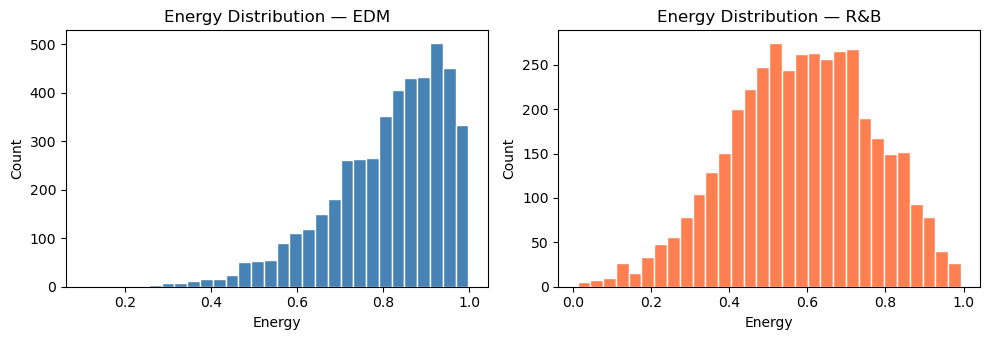

In [5]:
# These histograms are provided — run this cell as-is (Do NOT modify the code)

import matplotlib.pyplot as plt

edm_data = spotify_data[spotify_data['genre'] == 'edm']
rnb_data = spotify_data[spotify_data['genre'] == 'r&b']

plt.figure(figsize=(10, 3.5))

plt.subplot(1, 2, 1)
plt.hist(edm_data['energy'], bins=30, color='steelblue', edgecolor='white')
plt.title('Energy Distribution — EDM')
plt.xlabel('Energy')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(rnb_data['energy'], bins=30, color='coral', edgecolor='white')
plt.title('Energy Distribution — R&B')
plt.xlabel('Energy')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Plotting the EDM Energy KDE

* Plot a **Kernel Density Estimate (KDE)** of the `energy` scores for EDM tracks.

* Use `gaussian_kde` from `scipy.stats` and evaluate it over evenly spaced x-values with `np.linspace`.

* Your curve should be smooth (not jagged like a histogram). Fill the area under the curve with a light color. (You may use `matplotlib`'s `fill_between()` function.)

* Include a title and labeled axes.

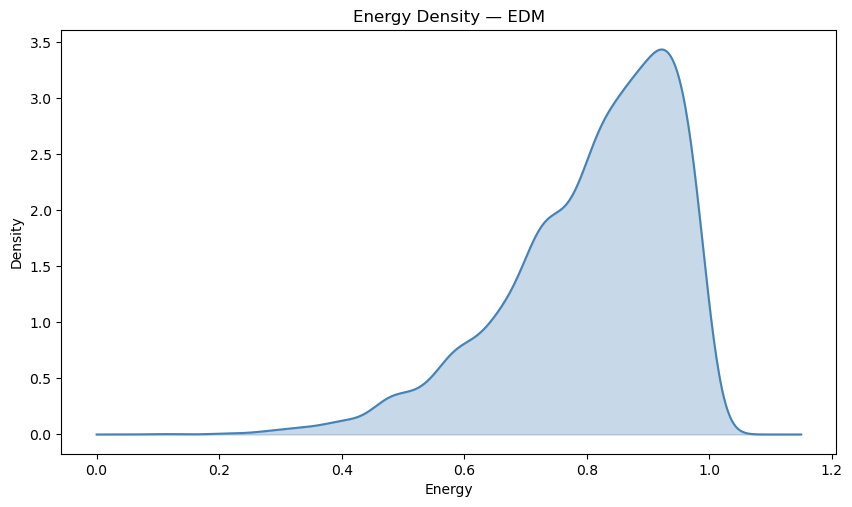

In [6]:
# WRITE YOUR CODE HERE
from scipy.stats import gaussian_kde as kde
import numpy as np
x = np.linspace(0, 1.15, 500)
edm_kde = kde(edm_data['energy'])
plt.figure(figsize=(10, 5.5))
plt.plot(x, edm_kde(x), color='steelblue')
#fill the area under the curve with a light blue color
plt.fill_between(x, edm_kde(x), color='steelblue', alpha=0.3)
plt.title('Energy Density — EDM')
plt.xlabel('Energy')
plt.ylabel('Density')
plt.show()

### Interpreting the EDM Energy Distribution

* On **the same KDE plot**, add:
  1. A **vertical dashed line** at the mean `energy` value for EDM (use `plt.axvline`).
  2. A **horizontal dashed line** at the density corresponding to that mean, drawn from the left edge of the plot to the vertical line (use `plt.hlines`).<br><br>

* Label both lines in the legend, including the mean value and its corresponding density.

* Together, these two lines form an 'L-shape' that anchors the mean to its position on the density curve, making it easy to read both the value and its corresponding density at a glance.

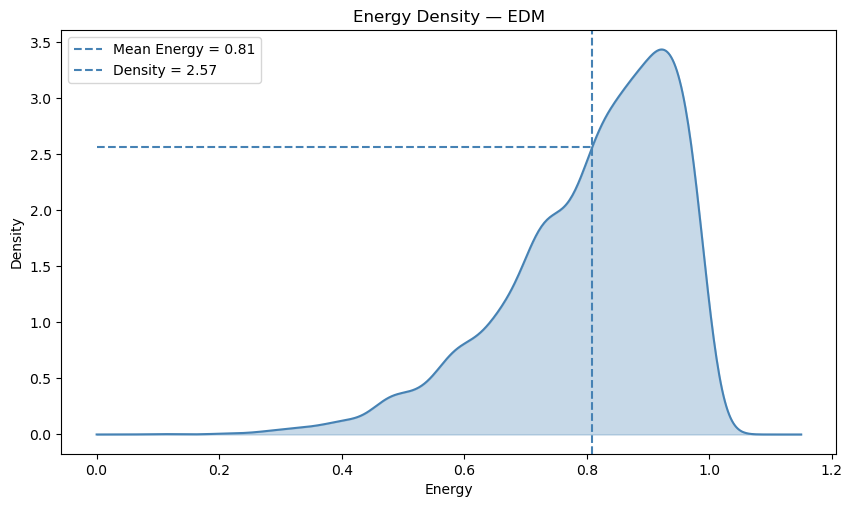

In [7]:
# WRITE YOUR CODE HERE
#add a vertical line to the plot at the mean energy for each genre
plt.figure(figsize=(10, 5.5))
plt.axvline(edm_mean_energy, color='steelblue', linestyle='--', label=f'Mean Energy = {edm_mean_energy:.2f}')
#add a horizontal line at the density value corresponding to the mean energy for each genre
edm_density_at_mean = edm_kde(edm_mean_energy).item()
plt.hlines(edm_density_at_mean, 0, edm_mean_energy, color='steelblue', linestyle='--', label=f'Density = {edm_density_at_mean:.2f}')
plt.legend()
plt.plot(x, edm_kde(x), color='steelblue')
#fill the area under the curve with a light blue color
plt.fill_between(x, edm_kde(x), color='steelblue', alpha=0.3)
plt.title('Energy Density — EDM')
plt.xlabel('Energy')
plt.ylabel('Density')
plt.show()

### Probability of Very High Energy

* Using your KDE object, compute the probability that a randomly selected EDM track has an `energy` score **greater than 0.9**.

  * The KDE object provides the `integrate_box_1d(lower, upper)` method that computes the area under the curve between two values. Carefully consider what the upper bound should be when calculating a probability *above* a threshold.<br><br>

* On the same plot from above, shade the region where `energy > 0.9` using `plt.fill_between` with a contrasting color.

* Include the computed probability in the existing legend.

* Report the probability value.

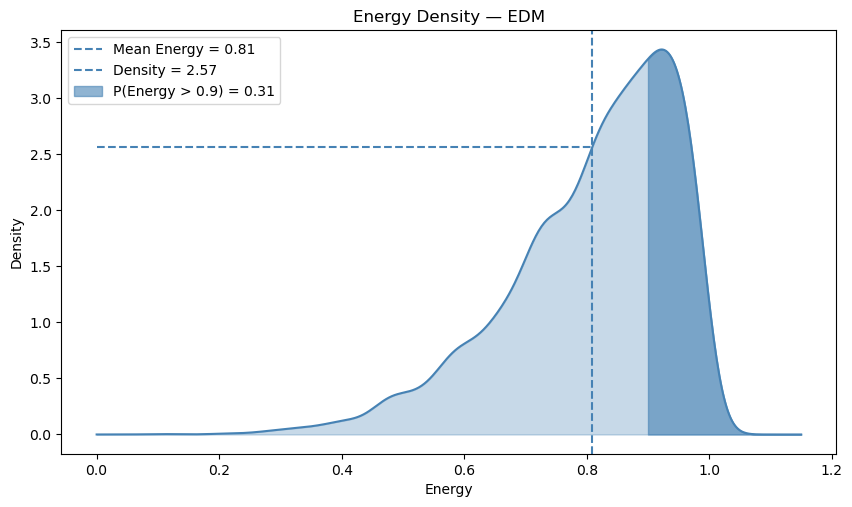

The probability of an EDM song having an energy score above 0.9 is approximately 0.31.


In [8]:
# WRITE YOUR CODE HERE
#calculate the probability of a song having an energy score above .9 for edm
edm_above_90 = edm_kde.integrate_box_1d(0.9, np.inf) #need to integrate to infinity since the kde is continous past 1 even thoough the score is capped at 1

plt.figure(figsize=(10, 5.5))
plt.axvline(edm_mean_energy, color='steelblue', linestyle='--', label=f'Mean Energy = {edm_mean_energy:.2f}')

#add a horizontal line at the density value corresponding to the mean energy for each genre
edm_density_at_mean = edm_kde(edm_mean_energy).item()
plt.hlines(edm_density_at_mean, 0, edm_mean_energy, color='steelblue', linestyle='--', label=f'Density = {edm_density_at_mean:.2f}')
plt.legend()
plt.plot(x, edm_kde(x), color='steelblue')

#fill the area under the curve with a light blue color
plt.fill_between(x, edm_kde(x), color='steelblue', alpha=0.3)
plt.title('Energy Density — EDM')

#fill the area under the curve for energy scores above .9 with a darker blue color
x_fill = np.linspace(0.9, 1.15, 100)
plt.fill_between(x_fill, edm_kde(x_fill), color='steelblue', alpha=0.6, label=f'P(Energy > 0.9) = {edm_above_90:.2f}')
plt.legend()
plt.xlabel('Energy')
plt.ylabel('Density')
plt.show()
print(f'The probability of an EDM song having an energy score above 0.9 is approximately {edm_above_90:.2f}.')

### Comparing EDM and R&B Energy Distributions

* Plot the **EDM** and **R&B** energy KDE curves on the **same axes** (i.e., in a single plot).

* Use a different colour for each genre. Include a legend, title, and labeled axes.

* Based on the plot, discuss whether the average energy differs between the two genres, and provide an explanation for your reasoning.

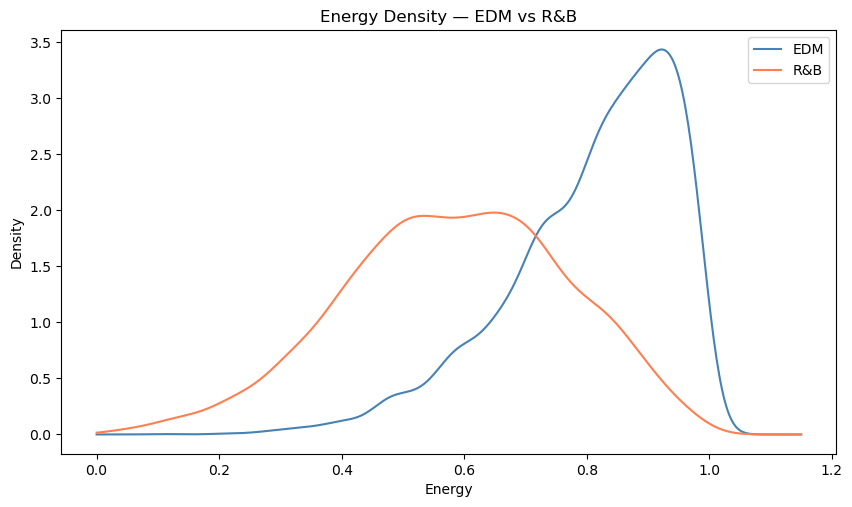

In [9]:
# WRITE YOUR CODE HERE
rnb_kde = kde(rnb_data['energy'])
plt.figure(figsize=(10, 5.5))
plt.plot(x, edm_kde(x), color='steelblue')
plt.plot(x, rnb_kde(x), color='coral')
plt.title('Energy Density — EDM vs R&B')
plt.xlabel('Energy')
plt.ylabel('Density')
plt.legend(['EDM', 'R&B'])
plt.show()


> **WRITE YOUR ANSWER HERE:**
<br>
> Based on the plot I would say the average energy differs between the two genres. While the r&b curve is symetrical and bell shaped arround the mean the EDM curve is right shifted where most of the songs have an energy score above .8. This is consistent with my understanding of the two genres. EDM is designed to be high energy and intense while r&b is more laid back and smooth. The plot shows that the average energy for EDM is higher than R&B and that there are more songs with very high energy in the EDM genre compared to R&B.

### Hypothesis Testing

* Is there a **statistically significant difference** in mean energy between EDM and R&B tracks?

  * **Null Hypothesis ($H_0$):** The mean energy score is the same for EDM and R&B. Any observed difference is due to chance (sampling variation).

  * **Alternative Hypothesis ($H_A$):** The mean energy scores differ between the two genres. The observed difference is unlikely to be due to chance alone.

* We will use a **permutation test**. The key idea: if $H_0$ is true, the genre labels carry no real information — we can randomly shuffle them, and the resulting differences should be similar in magnitude to the difference we actually observed.

### Extracting the Data

* Combine the `energy` values from EDM and R&B into a **single NumPy array** called `energy_edm_rnb`.

  * We use a NumPy array here (rather than a pandas Series) because the permutation test requires `np.random.shuffle`, which operates on NumPy arrays.<br><br>

* Print the length of the EDM and R&B data, aw well as the combined array, to confirm the total number of tracks.

In [10]:
# WRITE YOUR CODE HERE

energy_edm_rnb = np.concatenate([edm_data['energy'], rnb_data['energy']])
print(f'length of energy_edm_rnb: {len(energy_edm_rnb)}')
print(f'length of edm_data: {len(edm_data)}')
print(f'length of rnb_data: {len(rnb_data)}')
print(f'difference: {len(energy_edm_rnb) - (len(edm_data) + len(rnb_data))}')

length of energy_edm_rnb: 8670
length of edm_data: 4603
length of rnb_data: 4067
difference: 0


### Computing the Observed Test Statistic

* Our test statistic is the **difference in mean energy** between EDM and R&B:

$$\text{observed\_test\_stat} = \bar{x}_{\text{EDM}} - \bar{x}_{\text{R\&B}}$$

* Compute this value, save it to a variable called `observed_test_stat`, and print the value.

In [11]:
# WRITE YOUR CODE HERE
observed_test_stat = edm_mean_energy - r_and_b_mean_energy
print(f'Observed test statistic (difference in mean energy): {observed_test_stat:.2f}')


Observed test statistic (difference in mean energy): 0.22


### Simulating One Permutation

* Under the null hypothesis, EDM and R&B tracks come from the same distribution — so their labels are interchangeable.

* Simulate a **single permutation**:
  1. Shuffle `energy_edm_rnb` using `np.random.shuffle`. *(Work on a copy to avoid overwriting the original data.)*
  2. Draw two new samples with the **same sizes** as the original EDM and R&B groups.
  3. Compute the difference in means and save it to `perm_diff`. Print the result.

In [12]:
# WRITE YOUR CODE HERE
# one shuffle on the combined energy data copied to protect the original data
copy_energy_edm_rnb = energy_edm_rnb.copy()

# np.random.shuffle modifies the array in place
np.random.shuffle(copy_energy_edm_rnb)

# same sizes as edm_data and rnb_data
first_permutation = copy_energy_edm_rnb[:len(edm_data)]
second_permutation = copy_energy_edm_rnb[len(edm_data):]

perm_diff = first_permutation.mean() - second_permutation.mean()
print(f'Permuted test statistic (difference in mean energy): {perm_diff:.4f}')

Permuted test statistic (difference in mean energy): -0.0075


### Building the Null Distribution (Permutation Test, 5,000 iterations)

* Repeat the single-permutation procedure **5,000 times**, storing each resulting difference in an array called `perm_diffs`.

* Plot the distribution of permuted differences (a histogram works well).

* On the same plot, highlight the **observed test statistic** with:
  * A vertical dashed red line (`plt.axvline`).
  * A red scatter point at `y = 0` (`plt.scatter`).<br><br>

* Include a title, labeled axes, and a legend that displays the value of the observed test statistic.

In [13]:
# WRITE YOUR CODE HERE

np.random.seed(42)  # Do NOT change this seeding value
perm_diffs = []
for _ in range(5000):
    copy_energy_edm_rnb = energy_edm_rnb.copy()
    np.random.shuffle(copy_energy_edm_rnb)
    first_permutation = copy_energy_edm_rnb[:len(edm_data)]
    second_permutation = copy_energy_edm_rnb[len(edm_data):]
    perm_diff = first_permutation.mean() - second_permutation.mean()
    perm_diffs.append(perm_diff)


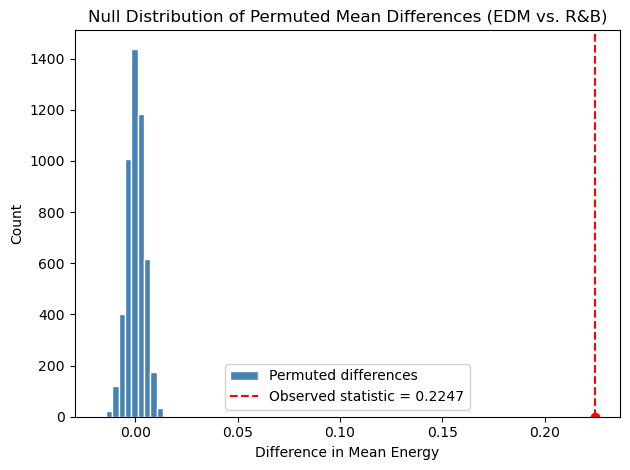

In [14]:
plt.hist(perm_diffs, bins=10, color='steelblue', edgecolor='white', label='Permuted differences')
plt.axvline(observed_test_stat, color='red', linestyle='--',
           label=f'Observed statistic = {observed_test_stat:.4f}')
plt.scatter(observed_test_stat, 0, color='red')

plt.title('Null Distribution of Permuted Mean Differences (EDM vs. R&B)')
plt.xlabel('Difference in Mean Energy')
plt.ylabel('Count')
plt.legend(framealpha=0.9)
plt.tight_layout()
plt.show()


### Computing the p-value

* The **p-value** is the proportion of permuted differences that are **at least as extreme** as the observed test statistic.

* Compute the p-value and print the result.

* Using $\alpha = 0.05$, state whether you **reject or fail to reject** $H_0$. Justify your answer based on the p-value.

In [15]:
# WRITE YOUR CODE HERE
#p_value

number_of_values_more_extreme = np.sum(np.abs(perm_diffs) >= np.abs(observed_test_stat))
p_value = number_of_values_more_extreme / len(perm_diffs)
print(f'Number of permuted differences as extreme as or more extreme than observed: {number_of_values_more_extreme}')
print(f'P-value: {p_value:.4f}')
print('Using a p-value threshold of 0.05, we would reject the null hypothesis that there is no difference in mean energy between EDM and R&B songs.')


Number of permuted differences as extreme as or more extreme than observed: 0
P-value: 0.0000
Using a p-value threshold of 0.05, we would reject the null hypothesis that there is no difference in mean energy between EDM and R&B songs.


### Hypothesis Test: Latin vs. Pop

* Repeat the full permutation test, this time comparing **`latin`** and **`pop`** tracks.

* Structure your code exactly as above:
  1. Filter and combine the energy values for both genres.
  2. Compute the observed test statistic as **Latin − Pop**.
  3. Run 5,000 permutations and store results in `perm_diffs_lat_pop`.
  4. Plot the permutation distribution with the observed test statistic marked.
  5. Compute the p-value.
  6. Print the p-value and state your conclusion.

* In the written-answer cell below, explain your findings. How does this result compare to the EDM vs. R&B test?

In [16]:
# WRITE YOUR CODE HERE

np.random.seed(42)  # Do NOT change this seeding value
# re-runt the permuation test for latin and pop genres
latin_data = spotify_data[spotify_data['genre'] == 'latin']
pop_data = spotify_data[spotify_data['genre'] == 'pop']
latin_mean_energy = latin_data['energy'].mean()
pop_mean_energy = pop_data['energy'].mean()
observed_test_stat_latin_pop = latin_mean_energy - pop_mean_energy
print(f'The observed difference in mean energy between Latin and Pop songs is: {observed_test_stat_latin_pop:.4f}') 


The observed difference in mean energy between Latin and Pop songs is: 0.0069


In [17]:
latin_pop_energy = np.concatenate([latin_data['energy'], pop_data['energy']])
perm_diffs_lat_pop = []

for _ in range(5000):
    copy_latin_pop_energy = latin_pop_energy.copy()
    np.random.shuffle(copy_latin_pop_energy)
    perm_latin_mean = copy_latin_pop_energy[:len(latin_data)]
    perm_pop_mean = copy_latin_pop_energy[len(latin_data):]
    perm_diffs_lat_pop.append(perm_latin_mean.mean() - perm_pop_mean.mean())


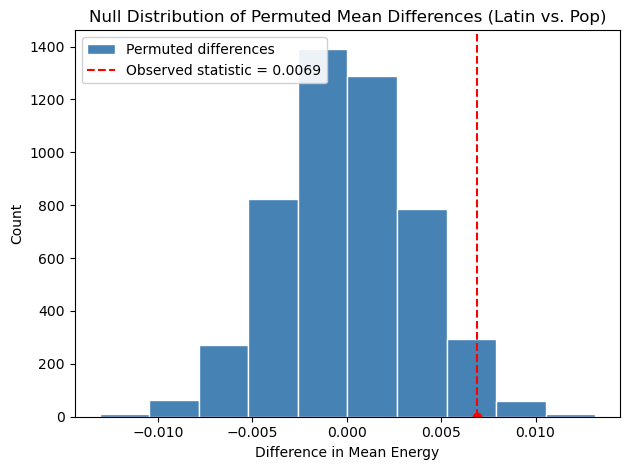

In [18]:
plt.hist(perm_diffs_lat_pop, bins=10, color='steelblue', edgecolor='white', label='Permuted differences')
plt.axvline(observed_test_stat_latin_pop, color='red', linestyle='--',
           label=f'Observed statistic = {observed_test_stat_latin_pop:.4f}')
plt.scatter(observed_test_stat_latin_pop, 0, color='red')

plt.title('Null Distribution of Permuted Mean Differences (Latin vs. Pop)')
plt.xlabel('Difference in Mean Energy')
plt.ylabel('Count')
plt.legend(framealpha=0.9)
plt.tight_layout()
plt.show()


In [19]:
#compute p-value for latin vs pop
number_of_values_more_extreme_latin_pop = np.sum(np.abs(perm_diffs_lat_pop) >= np.abs(observed_test_stat_latin_pop))
p_value_latin_pop = number_of_values_more_extreme_latin_pop / len(perm_diffs_lat_pop)
#print(f'Number of permuted differences as extreme as or more extreme than observed: {number_of_values_more_extreme}')
print(f'P-value: {p_value_latin_pop:.4f}')


P-value: 0.0570


> **WRITE YOUR ANSWER HERE:**
<br>
> At the p-value threshold of 0.05 we would fail to reject the null hypothesis. We have a p-value of 0.057 which is greater than our rejection threshold. This means that we do not have sufficient evidence to reject the null hypothesis that there is no difference in mean energy between Latin and Pop songs.

### Bonus: Hypothesis Testing Using SciPy [5 points]

In the previous sections you built a hypothesis test from scratch — combining data, shuffling, computing a test statistic, and constructing its null distribution manually.

In practice, Python's `scipy.stats` library can perform this kind of test in a single function call. Your task is to:

1. Identify the appropriate function in `scipy.stats` for comparing the means of two independent samples.
2. Apply it to the **EDM vs. R&B** comparison.
3. Compare the p-value from `scipy` with the one from your permutation test. Do they lead to the same conclusion?

In [20]:
# WRITE YOUR CODE HERE
#compare the means of two independent samples using scipy.stats.ttest_ind
from scipy.stats import ttest_ind
_ , p_value = ttest_ind(edm_data['energy'], rnb_data['energy'], equal_var=False)
print(f'P-value for EDM vs R&B in scipy stats ttest_ind: {p_value:.4f}')
print(f'This is approximately the same value as my permutation p-value, \nwhich shows that my permutation test is giving a \nconsistent result with the standard t-test \nfor independent samples.')

P-value for EDM vs R&B in scipy stats ttest_ind: 0.0000
This is approximately the same value as my permutation p-value, 
which shows that my permutation test is giving a 
consistent result with the standard t-test 
for independent samples.
